#  정보 검색 평가지표(HitRate, MRR, NDCG) 이해

- **정보 검색 평가 지표 이해**: HitRate, MRR, mAP, NDCG의 개념과 계산 방법 학습
- **Precision/Recall/F1 계산**: 검색 시스템의 정확도와 재현율 평가 방법 습득
- **ranx 라이브러리 기초**: IR 평가 라이브러리의 Qrels, Run, evaluate 개념 이해
- **ranx-k 라이브러리 활용**: 한국어 최적화 평가 (Kiwi 형태소 분석기 기반)
- **실전 검색 시스템 평가**: 실제 데이터셋을 활용한 성능 측정 및 분석

---

## 환경 설정 및 준비

**필요 라이브러리**
- `ranx`: IR 시스템 평가 라이브러리 (Qrels, Run, evaluate)
- `ranx-k`: 한국어 최적화 정보 검색 평가 라이브러리 (Kiwi 형태소 분석기 기반)

In [ ]:
# 검색 평가 라이브러리 설치
# uv pip install ranx      # IR 평가 라이브러리 (Qrels, Run, evaluate)
# uv pip install ranx-k    # 한국어 최적화 버전 (Kiwi 형태소 분석기 포함)

`(1) Env 환경변수`

In [ ]:
from dotenv import load_dotenv
load_dotenv()

`(2) 기본 라이브러리`

In [ ]:
import os
from glob import glob

from pprint import pprint
import json

`(3) langfuse handler 설정`

In [ ]:
from langfuse.langchain import CallbackHandler

# LangChain 콜백 핸들러 생성
langfuse_handler = CallbackHandler()

---

## **평가 지표** (Evaluation Metric)

#### 1) **검색(Retrieval) 평가**  

- **Non-Rank Based Metrics**: Accuracy, Precision, Recall@k 등을 통해 관련성의 이진적 평가를 수행  

- **Rank-Based Metrics**: MRR(Mean Reciprocal Rank), MAP(Mean Average Precision)를 통해 검색 결과의 순위를 고려한 평가를 수행

- **RAG 특화 지표**: 기존 검색 평가 방식의 한계를 보완하는 LLM-as-judge 방식 도입

- **포괄적 평가**: 정확도, 관련성, 다양성, 강건성을 통합적으로 측정

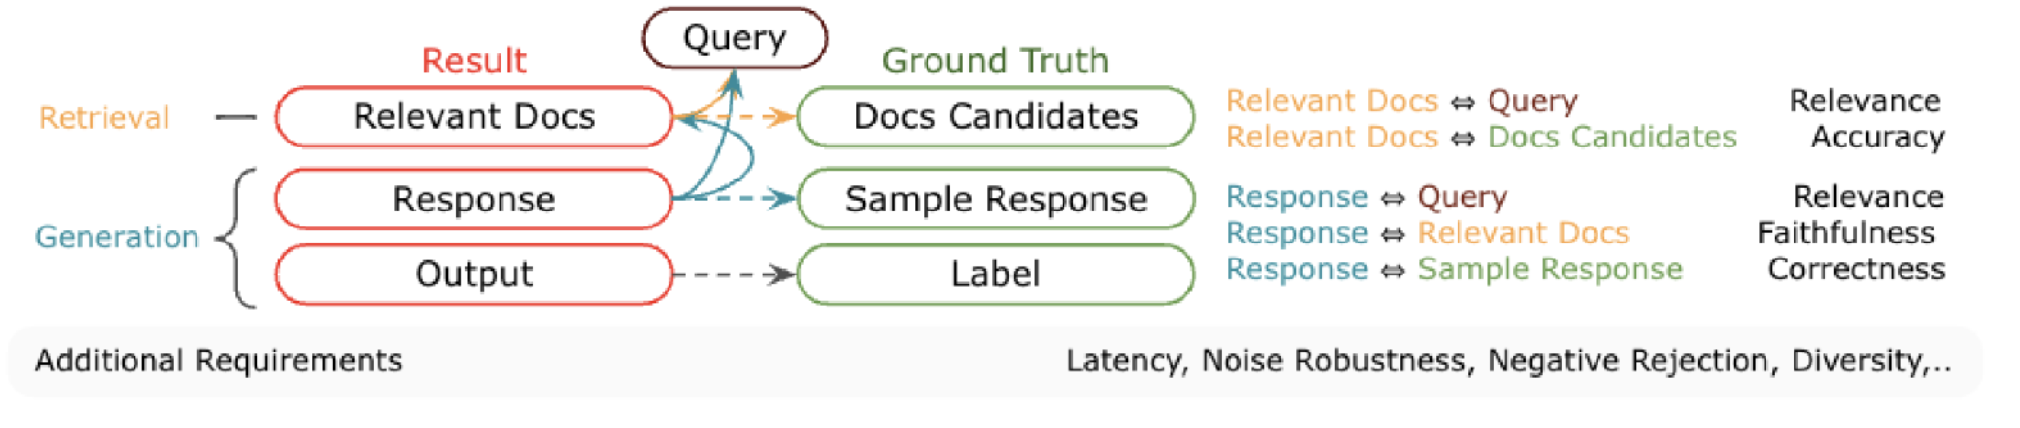


#### 2) **생성(Generation) 평가**

- **전통적 평가**: ROUGE(요약), BLEU(번역), BertScore(의미 유사도) 지표 활용

- **LLM 기반 평가**: 응집성, 관련성, 유창성을 종합적으로 판단하는 새로운 접근법 도입 (전통적인 참조 비교가 어려운 상황에서 유용)

- **다차원 평가**: 품질, 일관성, 사실성, 가독성, 사용자 만족도를 포괄적 측정

- **상세 프롬프트**와 **사용자 선호도** 기준으로 생성 텍스트 품질 평가


[출처] https://arxiv.org/abs/2405.07437

---

## **검색 성능 평가 데이터**

- 2개의 검색 쿼리에 대한 정답(실제 문서)와 검색 결과(예측 문서)를 준비

    1. 실제 문서(actual_docs):
        - 첫 번째 쿼리: 배송 지연(doc1), 결제 오류(doc2), 포인트 적립(doc5) 관련 문서
        - 두 번째 쿼리: 제품 교환(doc3)과 취소 환불(doc4) 관련 문서

    2. 예측 문서(predicted_docs):
        - 첫 번째 쿼리: doc1, doc2, doc5을 검색 결과로 반환
        - 두 번째 쿼리: doc6, doc4, doc5을 검색 결과로 반환

- 랭체인 문서 객체로 구현된 각 문서는 다음 정보를 포함:
    - 문의 내용(page_content)
    - 메타데이터(id, category, priority)

In [ ]:
from langchain_core.documents import Document
from textwrap import dedent

# 실제 문서 데이터 (정답)
actual_docs = [

    [
        Document(
        page_content=dedent("""
            고객 문의: 제품 배송 지연
            문의 일시: 2024-01-15 14:23
            고객명: 김지안
            문의 내용: 지난주 주문한 상품이 아직도 배송이 안 왔습니다.
                      언제쯤 받을 수 있을까요?
            처리 상태: 답변 완료
            담당자: 이수진
            """).strip(),
        metadata={"id": "doc1", "category": "배송", "priority": "높음"}
        ),

        Document(
        page_content=dedent("""
            고객 문의: 결제 오류
            문의 일시: 2024-01-15 15:30
            고객명: 이동현
            문의 내용: 결제 시도 중 오류가 발생했습니다.
                      카드 결제가 되지 않아요.
            처리 상태: 답변 완료
            담당자: 김태호
            """).strip(),
        metadata={"id": "doc2", "category": "결제", "priority": "높음"}
        ),

        Document(
        page_content=dedent("""
            고객 문의: 포인트 적립 문의
            문의 일시: 2024-01-17 16:10
            고객명: 최서연
            문의 내용: 지난 구매 건에 대한 포인트가 적립이 안 되었습니다.
                      확인 부탁드립니다.
            처리 상태: 답변 대기
            담당자: 미배정
            """).strip(),
        metadata={"id": "doc5", "category": "포인트/적립", "priority": "낮음"}
        ),

    ],

    [
        Document(
        page_content=dedent("""
            고객 문의: 제품 교환 요청
            문의 일시: 2024-01-16 09:45
            고객명: 박현우
            문의 내용: 받은 제품의 사이즈가 맞지 않아 교환하고 싶습니다.
                      교환 절차를 알려주세요.
            처리 상태: 진행중
            담당자: 정미영
            """).strip(),
        metadata={"id": "doc3", "category": "교환/반품", "priority": "중간"}
        ),

        Document(
        page_content=dedent("""
            고객 문의: 취소 환불 문의
            문의 일시: 2024-01-16 11:20
            고객명: 장민서
            문의 내용: 주문을 취소하고 싶습니다.
                      환불은 얼마나 걸리나요?
            처리 상태: 답변 완료
            담당자: 홍길동
            """).strip(),
        metadata={"id": "doc4", "category": "취소/환불", "priority": "중간"}
        ),
    ]

]

# 예측 문서 데이터 (검색 결과)
predicted_docs = [

    [
        Document(
        page_content=dedent("""
            고객 문의: 제품 배송 지연
            문의 일시: 2024-01-15 14:23
            고객명: 김지안
            문의 내용: 지난주 주문한 상품이 아직도 배송이 안 왔습니다.
                      언제쯤 받을 수 있을까요?
            처리 상태: 답변 완료
            담당자: 이수진
            """).strip(),
        metadata={"id": "doc1", "category": "배송", "priority": "높음"}
    ),
        Document(
        page_content=dedent("""
            고객 문의: 결제 오류
            문의 일시: 2024-01-15 15:30
            고객명: 이동현
            문의 내용: 결제 시도 중 오류가 발생했습니다.
                      카드 결제가 되지 않아요.
            처리 상태: 답변 완료
            담당자: 김태호
            """).strip(),
        metadata={"id": "doc2", "category": "결제", "priority": "높음"}
    ),
        Document(
        page_content=dedent("""
            고객 문의: 포인트 적립 문의
            문의 일시: 2024-01-17 16:10
            고객명: 최서연
            문의 내용: 지난 구매 건에 대한 포인트가 적립이 안 되었습니다.
                      확인 부탁드립니다.
            처리 상태: 답변 대기
            담당자: 미배정
            """).strip(),
        metadata={"id": "doc5", "category": "포인트/적립", "priority": "낮음"}
        ),
    ],

    [

        Document(
        page_content=dedent("""
            고객 문의: 상품 재입고 문의
            문의 일시: 2024-01-17 17:45
            고객명: 한승우
            문의 내용: 품절된 상품의 재입고 일정이 궁금합니다.
                        알림 신청은 어떻게 하나요?
            처리 상태: 답변 대기
            담당자: 미배정
            """).strip(),
        metadata={"id": "doc6", "category": "재고", "priority": "중간"}
        ),

        Document(
        page_content=dedent("""
            고객 문의: 취소 환불 문의
            문의 일시: 2024-01-16 11:20
            고객명: 장민서
            문의 내용: 주문을 취소하고 싶습니다.
                      환불은 얼마나 걸리나요?
            처리 상태: 답변 완료
            담당자: 홍길동
            """).strip(),
        metadata={"id": "doc4", "category": "취소/환불", "priority": "중간"}
        ),

        Document(
        page_content=dedent("""
            고객 문의: 포인트 적립 문의
            문의 일시: 2024-01-17 16:10
            고객명: 최서연
            문의 내용: 지난 구매 건에 대한 포인트가 적립이 안 되었습니다.
                      확인 부탁드립니다.
            처리 상태: 답변 대기
            담당자: 미배정
            """).strip(),
        metadata={"id": "doc5", "category": "포인트/적립", "priority": "낮음"}
        ),

    ]

]


# 문서 ID 출력
actual_ids = [[doc.metadata["id"] for doc in docs] for docs in actual_docs]
predicted_ids = [[doc.metadata["id"] for doc in docs] for docs in predicted_docs]

print("실제 문서 ID:", actual_ids)
print("예측 문서 ID:", predicted_ids)

---

## **검색 성능 평가**  

- 문서 검색 시스템의 성능은 **정확도**와 **재현율**을 통해 평가됨
- **정밀도(Precision)** 지표는 검색된 문서 중 관련 문서의 비율을 측정
- **재현율(Recall)** 지표는 전체 관련 문서 중 실제로 검색된 문서의 비율을 나타냄
- **F1 점수**는 정밀도와 재현율의 조화 평균으로 종합적 성능을 평가
- 효과적인 검색 시스템은 정확도와 재현율 간의 **최적의 균형**을 찾는 것이 중요함

---
### 1) **TP, FP, FN** 계산

1. True Positive (TP):
   - **실제로 관련 있는 문서를 정확하게 검색한 경우**
   - 첫 번째 쿼리에서는 doc1, doc2, doc5를 정확히 검색
   - 두 번째 쿼리에서는 doc4를 정확히 검색

2. False Positive (FP):
   - **실제로는 관련 없는 문서를 잘못 검색한 경우**
   - 첫 번째 쿼리에서는 불필요한 검색이 없음
   - 두 번째 쿼리에서는 doc5, doc6을 불필요하게 검색

3. False Negative (FN):
   - **실제로는 관련 있는 문서를 검색하지 못한 경우**
   - 첫 번째 쿼리에서는 모든 관련 문서를 검색
   - 두 번째 쿼리에서는 doc3을 검색하지 못함

In [ ]:
# True Positive - 예측 문서 중 실제 문서와 일치하는 문서
true_positives = [
    [doc.metadata["id"] for doc in actual if doc in predicted]
    for actual, predicted in zip(actual_docs, predicted_docs)
]

# False Positive - 예측 문서 중 실제 문서와 일치하지 않는 문서
false_positives = [
    [doc.metadata["id"] for doc in predicted if doc not in actual]
    for actual, predicted in zip(actual_docs, predicted_docs)
]

# False Negative - 실제 문서 중 예측 문서와 일치하지 않는 문서
false_negatives = [
    [doc.metadata["id"] for doc in actual if doc not in predicted]
    for actual, predicted in zip(actual_docs, predicted_docs)
]

print("True Positive:", true_positives)
print("False Positive:", false_positives)
print("False Negative:", false_negatives)

---
### 2) **Precision, Recall, F1 Score** 계산

- **정밀도(Precision)** = (검색된 문서 중 관련 문서 수) / (검색된 총 문서 수)
- **재현율(Recall)** = (검색된 관련 문서 수) / (전체 관련 문서 수)
- **F1 Score** = 2 × (정밀도 × 재현율) / (정밀도 + 재현율)
- 성능 평가는 **문서셋과 검색 쿼리**에 대해 각각 계산하여 평균값 사용

In [ ]:
# 각 쿼리별 성능 분석
for i, (tp, fp, fn) in enumerate(zip(true_positives, false_positives, false_negatives)):
    print(f"\n쿼리 {i+1} 분석:")
    print(f"정확하게 검색된 문서 (TP): {tp}")
    print(f"잘못 검색된 문서 (FP): {fp}")
    print(f"놓친 문서 (FN): {fn}")

    # 정밀도와 재현율 계산
    precision = len(tp) / (len(tp) + len(fp)) if len(tp) + len(fp) > 0 else 0
    recall = len(tp) / (len(tp) + len(fn)) if len(tp) + len(fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if precision + recall > 0 else 0

    print(f"정밀도 (Precision): {precision:.2f}")
    print(f"재현율 (Recall): {recall:.2f}")
    print(f"F1 Score: {f1:.2f}")

---
### 3) **Micro/Macro Average** 계산

- **Micro Average**는 전체 데이터셋의 개별 결과를 합산하여 계산
- **Macro Average**는 각 클래스(쿼리)별 성능 지표를 먼저 계산한 후 평균을 구함
- **Micro**는 데이터 불균형에 덜 민감하며 **전체적 성능** 평가에 적합
- **Macro**는 각 클래스(쿼리)의 성능을 동등하게 고려하여 **소수 클래스** 성능도 중요하게 반영

`(1) Macro Average (매크로 평균)`

- **매크로 평균**은 각 클래스(쿼리)별 성능 지표(Precision, Recall, F1)을 독립적으로 계산 후 평균값 산출
- 수식: **Macro-Precision** = $\frac{1}{n}\sum_{i=1}^{n} P_i$
- 수식: **Macro-Recall** = $\frac{1}{n}\sum_{i=1}^{n} R_i$
- 각 클래스(쿼리)는 **동일한 가중치**로 평가되어 소수 클래스의 성능도 중요하게 반영됨

In [ ]:
from typing import List, Tuple
import numpy as np

def calculate_macro_metrics(
    true_positives: List[List],
    false_positives: List[List],
    false_negatives: List[List]
) -> Tuple[float, float, float]:
    """
    Macro-average 방식으로 Precision, Recall, F1 Score를 계산합니다.
    각 클래스별 메트릭을 먼저 계산한 후 평균을 냅니다.

    Args:
        true_positives (List[List]): 각 클래스별 true positive 케이스들의 리스트
        false_positives (List[List]): 각 클래스별 false positive 케이스들의 리스트
        false_negatives (List[List]): 각 클래스별 false negative 케이스들의 리스트

    Returns:
        Tuple[float, float, float]: (macro_precision, macro_recall, macro_f1) 값을 반환
    """
    n_classes = len(true_positives)
    precisions = []
    recalls = []
    f1_scores = []

    for i in range(n_classes):
        tp = len(true_positives[i])
        fp = len(false_positives[i])
        fn = len(false_negatives[i])

        # Precision 계산
        precision = tp / (tp + fp) if (tp + fp) > 0 else 0
        precisions.append(precision)

        # Recall 계산
        recall = tp / (tp + fn) if (tp + fn) > 0 else 0
        recalls.append(recall)

        # F1 Score 계산
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
        f1_scores.append(f1)

        print(f"Class {i+1}: Precision={precision:.3f}, Recall={recall:.3f}, F1 Score={f1:.3f}")

    # 각 메트릭의 평균을 계산
    macro_precision = np.mean(precisions)
    macro_recall = np.mean(recalls)
    macro_f1 = np.mean(f1_scores)

    return macro_precision, macro_recall, macro_f1   # type: ignore


# Macro-average 방식으로 Precision, Recall, F1 Score 계산
macro_precision, macro_recall, macro_f1 = calculate_macro_metrics(true_positives, false_positives, false_negatives)

print("\nMacro-average Metrics:")
print(f"Macro-average Precision: {macro_precision:.2f}")
print(f"Macro-average Recall: {macro_recall:.2f}")
print(f"Macro-average F1 Score: {macro_f1:.2f}")

`(2) Micro Average (마이크로 평균)`

- **마이크로 평균**은 전체 데이터셋의 TP, FP, FN을 먼저 통합하여 계산
- 수식: **Micro-Precision** = $\frac{\sum_{i=1}^{n} TP_i}{\sum_{i=1}^{n} (TP_i + FP_i)}$
- 수식: **Micro-Recall** = $\frac{\sum_{i=1}^{n} TP_i}{\sum_{i=1}^{n} (TP_i + FN_i)}$
- **데이터 수가 많은 클래스**가 전체 성능에 더 큰 영향을 미침

In [ ]:
from typing import List, Tuple

def calculate_micro_metrics(
    true_positives: List[List],
    false_positives: List[List],
    false_negatives: List[List]
) -> Tuple[float, float, float]:
    """
    Micro-average 방식으로 Precision, Recall, F1 Score를 계산합니다.
    모든 클래스의 TP, FP, FN을 합산한 후 메트릭을 계산합니다.

    Args:
        true_positives (List[List]): 각 클래스별 true positive 케이스들의 리스트
        false_positives (List[List]): 각 클래스별 false positive 케이스들의 리스트
        false_negatives (List[List]): 각 클래스별 false negative 케이스들의 리스트

    Returns:
        Tuple[float, float, float]: (micro_precision, micro_recall, micro_f1) 값을 반환
    """
    # 전체 TP, FP, FN 합계 계산
    total_tp = sum(len(tp) for tp in true_positives)
    total_fp = sum(len(fp) for fp in false_positives)
    total_fn = sum(len(fn) for fn in false_negatives)

    # Micro Precision
    micro_precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0

    # Micro Recall
    micro_recall = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0

    # Micro F1 Score
    micro_f1 = 2 * micro_precision * micro_recall / (micro_precision + micro_recall) \
        if (micro_precision + micro_recall) > 0 else 0

    return micro_precision, micro_recall, micro_f1


# Micro-average 방식으로 Precision, Recall, F1 Score 계산

micro_precision, micro_recall, micro_f1 = calculate_micro_metrics(true_positives, false_positives, false_negatives)

print("\nMicro-average Metrics:")
print(f"Micro-average Precision: {micro_precision:.2f}")
print(f"Micro-average Recall: {micro_recall:.2f}")
print(f"Micro-average F1 Score: {micro_f1:.2f}")

---

## **Information Retrieval** 평가지표

- **Hit Rate**는 0~1 사이의 값으로 검색된 문서 중 실제 관련 있는 문서의 비율을 측정하며, **순서를 고려하지 않은** 기본적인 평가 지표임

- **Mean Reciprocal Rank (MRR)** 은 첫 번째 관련 문서가 등장하는 순위의 역수를 평균 내어 계산하며, **검색 결과의 순서를 고려**한 평가가 가능함

- **Mean Average Precision (mAP@k)** 는 상위 k개 문서 내에서 관련 문서 검색의 정확도를 평균화하여 산출함

- **NDCG@k**는 문서의 관련성과 검색 순위를 동시에 고려하여 이상적인 순위와 비교한 정규화 점수를 제공하는 **종합적인** 평가 지표임

- 이러한 평가 지표들은 RAG 시스템의 **검색 품질**을 다각도로 분석하여 성능 개선에 활용됨

In [ ]:
# 기본 ranx 라이브러리를 사용한 샘플 데이터 평가
# 샘플 데이터는 정답 청크와 예측 청크가 동일하므로 정확 일치 또는 ROUGE 기반 비교 가능

from ranx import Qrels, Run, evaluate
from kiwipiepy import Kiwi
from typing import List, Dict

def evaluate_with_ranx(
    actual_docs: List[List], 
    predicted_docs: List[List], 
    k: int = 10,
    rouge_threshold: float = 0.8
) -> Dict[str, float]:
    """
    기본 ranx 라이브러리를 사용한 검색 평가 (Kiwi ROUGE 매칭 기반)
    
    ⚠️ 이 함수는 actual_docs와 predicted_docs가 이미 준비된 경우에 사용합니다.
    실제 RAG 시스템에서는 retriever 객체를 직접 받는 ranx-k 함수를 사용하세요.
    
    Args:
        actual_docs: 정답 문서 리스트 (List[List[Document]])
        predicted_docs: 검색된 문서 리스트 (List[List[Document]])
        k: 상위 k개 문서만 평가
        rouge_threshold: ROUGE 매칭 임계값 (1.0 = 정확 일치, 0.8 = 유사도 기반)
        
    Returns:
        Dict: hit_rate, mrr, map, ndcg 점수
    """
    kiwi = Kiwi()
    
    def get_content(doc) -> str:
        """Document 또는 문자열에서 내용 추출"""
        return doc.page_content if hasattr(doc, 'page_content') else str(doc)
    
    def calculate_rouge_f1(text1: str, text2: str) -> float:
        """Kiwi 토큰화 기반 ROUGE F1 점수 계산"""
        tokens1 = set(t.form for t in kiwi.tokenize(text1))
        tokens2 = set(t.form for t in kiwi.tokenize(text2))
        
        if not tokens1 or not tokens2:
            return 0.0
        
        intersection = tokens1 & tokens2
        precision = len(intersection) / len(tokens2)
        recall = len(intersection) / len(tokens1)
        
        if precision + recall == 0:
            return 0.0
        return 2 * precision * recall / (precision + recall)
    
    qrels_dict = {}
    run_dict = {}
    
    for i, (actual_list, predicted_list) in enumerate(zip(actual_docs, predicted_docs)):
        query_id = f"q_{i+1}"
        qrels_dict[query_id] = {}
        run_dict[query_id] = {}
        
        # 예측 문서를 순서대로 등록 (모든 예측 문서에 고유 ID 부여)
        # ranx가 올바른 순위를 계산하려면 모든 예측 문서의 순서를 알아야 함
        for rank, pred_doc in enumerate(predicted_list[:k]):
            pred_content = get_content(pred_doc)
            pred_id = f"q{i+1}_pred_{rank}"  # 예측 문서 고유 ID
            
            # run_dict에 등록 (점수 = k - rank, 높을수록 상위)
            run_dict[query_id][pred_id] = k - rank
            
            # 이 예측 문서가 어떤 정답 문서와 매칭되는지 확인
            for j, actual_doc in enumerate(actual_list):
                actual_content = get_content(actual_doc)
                rouge_score = calculate_rouge_f1(actual_content, pred_content)
                
                if rouge_score >= rouge_threshold:
                    # 매칭된 경우: qrels에 이 예측 문서 ID를 관련 문서로 등록
                    qrels_dict[query_id][pred_id] = 1
                    break
    
    # ranx 평가
    qrels = Qrels(qrels_dict, name="ground_truth")
    run = Run(run_dict, name="predictions")
    
    metrics = [f"hit_rate@{k}", f"mrr@{k}", f"map@{k}", f"ndcg@{k}"]
    results = evaluate(qrels, run, metrics)
    
    return {
        'hit_rate': results.get(f'hit_rate@{k}', 0.0),
        'mrr': results.get(f'mrr@{k}', 0.0),
        'map': results.get(f'map@{k}', 0.0),
        'ndcg': results.get(f'ndcg@{k}', 0.0),
    }

print("ranx 기반 평가 함수 정의 완료")

In [ ]:
# 샘플 데이터 평가 (텍스트 정확 일치 - rouge_threshold=1.0)
results = evaluate_with_ranx(actual_docs, predicted_docs, k=3, rouge_threshold=1.0)

print("정확 일치 기반 평가 결과:")
pprint(results)

In [ ]:
# 샘플 데이터 평가 (ROUGE 유사도 기반 - rouge_threshold=0.8)
rouge_results = evaluate_with_ranx(actual_docs, predicted_docs, k=3, rouge_threshold=0.8)

print("ROUGE 유사도 기반 평가 결과 (threshold=0.8):")
pprint(rouge_results)

### 1) **Hit Rate** (적중률)

- 정보 검색 시스템의 성능을 측정하는 기본적인 평가 지표로, 검색 결과 상위 K개 중 **관련 문서가 하나라도 포함**되어 있는지를 이진법(1 또는 0)으로 평가

- 계산 방식이 단순하여 직관적으로 이해하기 쉽고, 전체 검색 시스템의 기본적인 성능을 빠르게 파악할 수 있다는 장점이 있음

- 최종 값은 모든 검색 쿼리에 대한 평균값으로 산출되며, 0에서 1 사이의 값을 가지게 되는데, 1에 가까울수록 검색 시스템의 성능이 우수함을 의미함

**계산식:**

$$\text{Hit Rate@K} = \frac{1}{N} \sum_{i=1}^{N} \mathbf{1}[\text{상위 K개 중 관련 문서 존재}]$$

- $N$: 전체 쿼리 수
- $\mathbf{1}[\cdot]$: 조건이 참이면 1, 거짓이면 0

**참고:** Hit Rate@K는 "상위 K개 결과 중 관련 문서가 **하나라도** 있으면 1"로 계산됩니다.

---

**샘플 데이터:**
- 실제 문서 ID: `[['doc1', 'doc2', 'doc5'], ['doc3', 'doc4']]`
- 예측 문서 ID: `[['doc1', 'doc2', 'doc5'], ['doc6', 'doc4', 'doc5']]`

---

**Hit Rate@1** 계산

1. 쿼리 1:
   - 예측 상위 1개: [doc1]
   - doc1이 정답 [doc1, doc2, doc5]에 있음 ✓
   - Hit = 1

2. 쿼리 2:
   - 예측 상위 1개: [doc6]
   - doc6이 정답 [doc3, doc4]에 없음 ✗
   - Hit = 0

3. $\text{Hit Rate@1} = \frac{1 + 0}{2} = 0.500$

---

**Hit Rate@2** 계산

1. 쿼리 1:
   - 예측 상위 2개: [doc1, doc2]
   - doc1이 정답에 있음 ✓ (하나라도 있으면 Hit)
   - Hit = 1

2. 쿼리 2:
   - 예측 상위 2개: [doc6, doc4]
   - doc4가 정답 [doc3, doc4]에 있음 ✓
   - Hit = 1

3. $\text{Hit Rate@2} = \frac{1 + 1}{2} = 1.000$

---

**Hit Rate@3** 계산

1. 쿼리 1:
   - 예측 상위 3개: [doc1, doc2, doc5]
   - doc1이 정답에 있음 ✓
   - Hit = 1

2. 쿼리 2:
   - 예측 상위 3개: [doc6, doc4, doc5]
   - doc4가 정답에 있음 ✓
   - Hit = 1

3. $\text{Hit Rate@3} = \frac{1 + 1}{2} = 1.000$

In [ ]:
print("실제 문서 ID:", actual_ids)
print("예측 문서 ID:", predicted_ids)

In [ ]:
# 계산 방법 (k=1)
# 첫 번째 쿼리: doc1이 정답에 포함 → 1
# 두 번째 쿼리: doc6이 정답에 없음 → 0

hit_rate = (1 + 0) / 2
print("Hit Rate @1:", hit_rate)

In [ ]:
# 계산 방법 (k=2)
# 첫 번째 쿼리: doc1, doc2가 모두 정답에 포함 → 1
# 두 번째 쿼리: doc6은 오답이지만 doc4가 정답에 포함 → 1

hit_rate = (1 + 1) / 2
print("Hit Rate @2:", hit_rate)

In [ ]:
# 계산 방법 (k=3)
# 첫 번째 쿼리: doc1, doc2, doc5 모두 정답에 포함 → 1
# 두 번째 쿼리: doc4가 정답에 포함 → 1

hit_rate = (1 + 1) / 2
print("Hit Rate @3:", hit_rate)

In [ ]:
# 'Hit Rate' 계산 - ranx 사용
k_values = [1, 2, 3]

for k in k_values:
    result = evaluate_with_ranx(actual_docs, predicted_docs, k=k, rouge_threshold=1.0)
    print(f"Hit Rate @{k}: {result['hit_rate']:.3f}")

### 2) **MRR** (Mean Reciprocal Rank)

- MRR은 검색 결과에서 첫 번째로 등장하는 관련 문서의 순위를 기반으로 성능을 평가하는 지표로, 특히 사용자가 원하는 정보를 얼마나 빨리 찾을 수 있는지를 측정

- 계산 방법은 각 검색 쿼리별로 첫 번째 관련 문서의 순위의 역수(1/rank)를 구한 후, 전체 쿼리에 대한 평균을 계산

- MRR은 검색 결과의 순서를 고려하기 때문에, 단순히 관련 문서의 포함 여부만을 평가하는 Hit Rate보다 더 실용적인 성능 평가가 가능함

- 특히 사용자 경험(UX) 관점에서 중요한 의미를 가지며, 검색 시스템의 실질적인 유용성을 평가하는 데 효과적

**계산식:**

$$\text{MRR@K} = \frac{1}{N} \sum_{i=1}^{N} \frac{1}{\text{rank}_i}$$

- $N$: 전체 쿼리 수
- $\text{rank}_i$: 쿼리 $i$에서 첫 번째 관련 문서가 등장하는 순위 (상위 K개 내에서)
- K개 안에 관련 문서가 없으면 해당 쿼리의 기여는 0

**핵심 차이점 (Hit Rate vs MRR):**
- Hit Rate: 관련 문서 **존재 여부**만 평가 (있으면 1, 없으면 0)
- MRR: 관련 문서의 **위치**를 평가 (1위면 1, 2위면 0.5, 3위면 0.333...)

---

**샘플 데이터:**
- 실제 문서 ID: `[['doc1', 'doc2', 'doc5'], ['doc3', 'doc4']]`
- 예측 문서 ID: `[['doc1', 'doc2', 'doc5'], ['doc6', 'doc4', 'doc5']]`

---

**MRR@1** 계산

1. 쿼리 1:
   - 예측 상위 1개: [doc1]
   - doc1이 정답에 있음 ✓ → 1위에서 발견
   - Reciprocal Rank = 1/1 = 1.0

2. 쿼리 2:
   - 예측 상위 1개: [doc6]
   - doc6이 정답에 없음 ✗ → 상위 1개 내 관련 문서 없음
   - Reciprocal Rank = 0

3. $\text{MRR@1} = \frac{1.0 + 0}{2} = 0.500$

---

**MRR@2** 계산

1. 쿼리 1:
   - 예측 상위 2개: [doc1, doc2]
   - doc1이 **1위**에서 처음 발견됨 ✓
   - Reciprocal Rank = 1/1 = 1.0

2. 쿼리 2:
   - 예측 상위 2개: [doc6, doc4]
   - doc6(1위) ✗ → doc4가 **2위**에서 처음 발견됨 ✓
   - Reciprocal Rank = 1/2 = 0.5

3. $\text{MRR@2} = \frac{1.0 + 0.5}{2} = 0.750$

---

**MRR@3** 계산

1. 쿼리 1:
   - 예측 상위 3개: [doc1, doc2, doc5]
   - doc1이 **1위**에서 처음 발견됨 ✓
   - Reciprocal Rank = 1/1 = 1.0

2. 쿼리 2:
   - 예측 상위 3개: [doc6, doc4, doc5]
   - doc6(1위) ✗ → doc4가 **2위**에서 처음 발견됨 ✓
   - Reciprocal Rank = 1/2 = 0.5 (3위까지 봐도 최초 발견 위치는 2위)

3. $\text{MRR@3} = \frac{1.0 + 0.5}{2} = 0.750$

---

**MRR@K 결과 해석**

| K값 | MRR | 의미 |
|:---:|:---:|:-----|
| 1 | 0.500 | 첫 위치에서 50%의 쿼리만 정답 발견 |
| 2 | 0.750 | 쿼리 2에서 2위에 정답 발견하여 성능 향상 |
| 3 | 0.750 | K=2와 동일 (이미 더 좋은 위치에서 발견됨) |

**참고:** MRR은 "첫 번째 관련 문서"만 고려합니다. 쿼리 1의 경우 doc1, doc2, doc5가 모두 정답이지만, 1위의 doc1만 점수에 기여합니다.

In [ ]:
print("실제 문서 ID:", actual_ids)
print("예측 문서 ID:", predicted_ids)

In [ ]:
# 계산 방법 (k=1)
# 첫 번째 쿼리: doc1 문서가 가장 먼저 찾은 관련 문서이므로 rank는 1이 됨 -> 1/1
# 두 번째 쿼리: doc6은 실제 정답이 아님 -> 0

mrr = (1/1 + 0) / 2
print("Mean Reciprocal Rank:", mrr)

In [ ]:
# 계산 방법 (k=2)
# 첫 번째 쿼리: doc1 문서가 가장 먼저 찾은 관련 문서이므로 rank는 1이 됨 -> 1/1
# 두 번째 쿼리: 두 번째 위치한 doc4 문서가 가장 먼저 찾은 관련 문서이므로 rank는 2이 됨 -> 1/2

mrr = (1/1 + 1/2) / 2
print("Mean Reciprocal Rank:", mrr)

In [ ]:
# 계산 방법 (k=3)
# 첫 번째 쿼리: doc1 문서가 가장 먼저 찾은 관련 문서이므로 rank는 1이 됨 -> 1/1
# 두 번째 쿼리: 두 번째 위치한 doc4 문서가 가장 먼저 찾은 관련 문서이므로 rank는 2이 됨 -> 1/2

mrr = (1/1 + 1/2) / 2
print("Mean Reciprocal Rank:", mrr)

In [ ]:
# 'Mean Reciprocal Rank' 계산 - ranx 사용
for k in k_values:
    result = evaluate_with_ranx(actual_docs, predicted_docs, k=k, rouge_threshold=1.0)
    print(f"MRR @{k}: {result['mrr']:.3f}")

### 3) **mAP@k** (Mean Average Precision at k)

- mAP@k는 검색 결과의 품질을 평가하는 고급 지표로, 상위 k개의 검색 결과 내에서 관련 문서들의 순위와 정확도를 종합적으로 평가

- 단순히 관련 문서의 존재 여부나 첫 등장 순위뿐만 아니라, 상위 k개 결과 내에서 관련 문서들의 전반적인 분포와 순서까지 고려하여 더욱 세밀한 성능 평가가 가능

- 검색 서비스에서 사용자에게 가장 중요한 상위 검색 결과의 품질에 초점을 맞추고 있어, 실용적인 관점에서 시스템의 성능을 평가하는 데 매우 효과적

- 정보 검색 시스템의 실제 사용성과 가장 밀접하게 연관되어 있어, 현대 검색 엔진 개발에서 널리 사용되고 있음

In [ ]:
print("실제 문서 ID:", actual_ids)
print("예측 문서 ID:", predicted_ids)

**AP**(Average Precision)

- 계산식: (각 정답 문서 위치에서의 Precision의 합) / (발견된 관련 문서 수)

    $AP = \frac{\sum_{i=1}^{n} P(i) \times rel(i)}{\text{min}(k, |\text{발견된 관련 문서}|)}$

    - $P(i)$: i번째 위치에서의 Precision
    - $rel(i)$: i번째 문서가 정답이면 1, 아니면 0
    - $k$: 상위 k개 문서
    - $n$: 예측된 문서의 수


- 예시 케이스 (k=3):
    - 실제 정답: $R = \{doc3, doc4\}$
    - 예측 결과: $[doc6, doc4, doc5]$ → doc4만 정답 (2번째 위치)

    - $doc6$ (1위): 오답 → $P(1) \times rel(1) = 0$
    - $doc4$ (2위): 정답 → $P(2) \times rel(2) = \frac{1}{2} \times 1 = 0.5$
    - $doc5$ (3위): 오답 → $P(3) \times rel(3) = 0$

    - 발견된 관련 문서 수 = 1
    - 따라서, $AP = \frac{0.5}{1} = 0.5$

**참고:** ranx는 "발견된 관련 문서 수"로 정규화합니다. 일부 정의에서는 "전체 정답 문서 수"로 나누기도 합니다.

**mAP@k** (Mean Average Precision at k)

**ranx의 AP 계산 방식:**
- ranx는 AP를 계산할 때 **k 범위 내에서 발견된 관련 문서 수**로 정규화합니다.
- 즉, `AP = Σ(P(i) × rel(i)) / min(k, 검색된 관련 문서 수)`

- **mAP@1** 계산

   1. 쿼리 1의 AP@1:
      - 예측: [doc1], 정답에 포함 ✓
      - P(1) = 1, 관련 문서 1개 발견
      - AP@1 = 1/1 = 1.0

   2. 쿼리 2의 AP@1:
      - 예측: [doc6], 정답에 없음 ✗
      - 관련 문서 0개 발견
      - AP@1 = 0

   3. $mAP@1 = \frac{1.0 + 0}{2} = 0.500$

- **mAP@2** 계산

   1. 쿼리 1의 AP@2:
      - 예측: [doc1, doc2], 둘 다 정답 ✓✓
      - P(1) = 1, P(2) = 1, 관련 문서 2개 발견
      - AP@2 = (1 + 1) / 2 = 1.0

   2. 쿼리 2의 AP@2:
      - 예측: [doc6, doc4], doc4만 정답 ✗✓
      - P(2) = 1/2 = 0.5, 관련 문서 1개 발견
      - AP@2 = 0.5 / 1 = 0.5

   3. $mAP@2 = \frac{1.0 + 0.5}{2} = 0.750$

- **mAP@3** 계산

   1. 쿼리 1의 AP@3:
      - 예측: [doc1, doc2, doc5], 모두 정답 ✓✓✓
      - P(1) = 1, P(2) = 1, P(3) = 1, 관련 문서 3개 발견
      - AP@3 = (1 + 1 + 1) / 3 = 1.0

   2. 쿼리 2의 AP@3:
      - 예측: [doc6, doc4, doc5], doc4만 정답 ✗✓✗
      - P(2) = 0.5, 관련 문서 1개 발견
      - AP@3 = 0.5 / 1 = 0.5

   3. $mAP@3 = \frac{1.0 + 0.5}{2} = 0.750$

In [ ]:
# mAP 계산 - ranx 라이브러리 사용
for k in k_values:
    result = evaluate_with_ranx(actual_docs, predicted_docs, k=k, rouge_threshold=1.0)
    print(f"mAP@{k}: {result['map']:.3f}")

### 4) **NDCG** (Normalized Discounted Cumulative Gain)

- NDCG는 검색 및 추천 시스템의 순위 품질을 평가하는 고급 지표로, 단순히 관련성 여부뿐만 아니라 결과의 순서까지 고려하여 시스템의 성능을 평가

- 검색 결과의 위치에 따라 가중치를 다르게 부여 (상위에 있는 관련 문서에는 더 높은 가중치를, 하위에 있는 문서에는 더 낮은 가중치를 부여)

- NDCG는 이상적인 순위(ideal ranking)와 비교하여 정규화된 점수를 제공하므로, 다른 검색 결과나 시스템 간의 비교가 용이 (0~1 범위. 1에 가까울수록 이상적)

- 특히 사용자의 실제 만족도와 밀접한 관련이 있어, 현대의 검색 및 추천 시스템 평가에서 매우 중요하게 사용됨

- 기본 공식:
    - DCG@k = $\sum_{i=1}^k \frac{2^{rel_i} - 1}{\log_2(i+1)}$
        - $rel_i$는 i번째 문서의 관련성(이진의 경우 0 또는 1)
    - NDCG@k = DCG@k / IDCG@k

**ranx의 NDCG 계산:**

ranx는 IDCG를 계산할 때 **실제로 발견 가능한 관련 문서 수**를 기준으로 합니다.

- **NDCG@1** 계산

  1. 쿼리 1 (k=1):
    - 예측: [doc1] → 정답 ✓
    - DCG@1 = (2¹-1)/log₂(2) = 1
    - IDCG@1 = 1 (최적의 경우 동일)
    - NDCG@1 = 1/1 = 1.0

  2. 쿼리 2 (k=1):
    - 예측: [doc6] → 오답 ✗
    - DCG@1 = 0
    - IDCG@1 = 1 (최적의 경우 정답이 1위)
    - NDCG@1 = 0/1 = 0

  3. 평균 NDCG@1: (1 + 0)/2 = **0.500**


- **NDCG@2** 계산

  1. 쿼리 1 (k=2):
    - 예측: [doc1, doc2] → 둘 다 정답 ✓✓
    - DCG@2 = 1/log₂(2) + 1/log₂(3) = 1 + 0.631 = 1.631
    - IDCG@2 = 1.631 (이미 최적)
    - NDCG@2 = 1.0

  2. 쿼리 2 (k=2):
    - 예측: [doc6, doc4] → doc4만 정답 ✗✓
    - DCG@2 = 0 + 1/log₂(3) = 0.631
    - IDCG@2 = 1/log₂(2) = 1 (k=2에서 가능한 정답 1개가 1위에 있는 경우)
    - NDCG@2 = 0.631/1 = 0.631

  3. 평균 NDCG@2: (1.0 + 0.631)/2 = **0.815**


- **NDCG@3** 계산

  1. 쿼리 1 (k=3):
    - 예측: [doc1, doc2, doc5] → 모두 정답 ✓✓✓
    - DCG@3 = 1 + 0.631 + 0.5 = 2.131
    - IDCG@3 = 2.131 (이미 최적)
    - NDCG@3 = 1.0

  2. 쿼리 2 (k=3):
    - 예측: [doc6, doc4, doc5] → doc4만 정답 ✗✓✗
    - DCG@3 = 0 + 0.631 + 0 = 0.631
    - IDCG@3 = 1 (k=3에서 정답 1개가 1위에 있는 경우)
    - NDCG@3 = 0.631/1 = 0.631

  3. 평균 NDCG@3: (1.0 + 0.631)/2 = **0.815**


**NDCG@k 결과 해석**

1. **NDCG@1 = 0.500**: 첫 위치만 봤을 때 50% 정확도 (쿼리 1 성공, 쿼리 2 실패)

2. **NDCG@2 = 0.815**: 상위 2개 결과에서 성능 향상 (쿼리 2에서 2위에 정답 발견)

3. **NDCG@3 = 0.815**: 3위까지 봐도 동일 (쿼리 2의 3위는 오답이므로 변화 없음)

In [ ]:
# NDCG 계산 - ranx 라이브러리 사용
for k in k_values:
    result = evaluate_with_ranx(actual_docs, predicted_docs, k=k, rouge_threshold=1.0)
    print(f"NDCG @{k}: {result['ndcg']:.3f}")

---

## 연습문제

다음 연습문제를 통해 검색 평가 지표에 대한 이해를 확인해 보세요.

**데이터:**
```python
# 정답 문서
actual = [['A', 'B', 'C'], ['D', 'E']]
# 예측 문서
predicted = [['A', 'C', 'F'], ['F', 'D', 'G']]
```

### 문제 1: Hit Rate 계산

아래 코드의 빈칸을 채워 Hit Rate@2를 계산하세요.

In [ ]:
# 연습문제 데이터
actual = [['A', 'B', 'C'], ['D', 'E']]
predicted = [['A', 'C', 'F'], ['F', 'D', 'G']]

def calculate_hit_rate(actual_docs, predicted_docs, k):
    """Hit Rate@k 계산"""
    hits = 0
    for actual_list, predicted_list in zip(actual_docs, predicted_docs):
        # 빈칸을 채우세요: 상위 k개 예측 중 정답이 하나라도 있으면 hit
        top_k_predictions = ____  # 힌트: predicted_list에서 상위 k개 슬라이싱
        
        for pred in top_k_predictions:
            if pred in ____:  # 힌트: 정답 리스트와 비교
                hits += 1
                break
    
    return hits / ____  # 힌트: 전체 쿼리 수로 나눔

# 테스트
hit_rate_2 = calculate_hit_rate(actual, predicted, k=2)
print(f"Hit Rate@2: {hit_rate_2}")

### 문제 2: MRR 계산

아래 코드의 빈칸을 채워 MRR@3을 계산하세요.

In [ ]:
def calculate_mrr(actual_docs, predicted_docs, k):
    """MRR@k 계산"""
    reciprocal_ranks = []
    
    for actual_list, predicted_list in zip(actual_docs, predicted_docs):
        rr = 0  # reciprocal rank
        for rank, pred in enumerate(predicted_list[:k], start=1):
            if pred in actual_list:
                # 빈칸을 채우세요: 첫 번째 정답의 역수 계산
                rr = ____  # 힌트: 1을 rank로 나눔
                break
        reciprocal_ranks.append(rr)
    
    # 빈칸을 채우세요: 평균 계산
    return ____(reciprocal_ranks) / len(reciprocal_ranks)

# 테스트
mrr_3 = calculate_mrr(actual, predicted, k=3)
print(f"MRR@3: {mrr_3}")

---

## [참고] ranx의 한계와 ranx-k

### 문제: 청크 사이즈 불일치

- 실제 RAG 시스템에서는 다음과 같은 상황이 발생합니다:

    ```mermaid
    graph LR
        A[원본 문서] -->|500자 청크로 분할| B[테스트셋 생성 시]
        B --> C[reference_contexts]
        A -->|300자 청크로 분할| D[벡터DB 구축 시]
        D --> E[검색 대상 문서]
    ```

- **결과:**
    - 테스트셋의 정답 청크와 벡터DB의 검색 청크가 **다른 크기**로 분할됨
    - 동일한 문서 ID가 존재하지 않음
    - **ranx의 ID 기반 비교가 불가능**

### 해결: ranx-k (텍스트 유사도 기반 매칭)

- `ranx-k`는 Kiwi 형태소 분석기를 활용하여 **텍스트 내용 기반**으로 문서를 매칭합니다.

    ```python
    # ID 기반 비교 (ranx 기본)
    if doc_id_actual == doc_id_predicted:  # ❌ 청크 사이즈가 다르면 불가능
        match = True

    # 텍스트 유사도 기반 비교 (ranx-k)
    rouge_score = calculate_kiwi_rouge(actual_text, predicted_text)
    if rouge_score >= threshold:  # ✅ 내용이 유사하면 매칭
        match = True
    ```

---

### ranx-k 평가 함수 상세 설명

ranx-k는 retriever 객체를 직접 받아 평가하는 3가지 주요 함수를 제공합니다.

#### 1) `simple_kiwi_rouge_evaluation`

**기본 Kiwi ROUGE 평가** - 가장 단순하고 빠른 방식

```python
from ranx_k.evaluation import simple_kiwi_rouge_evaluation

results = simple_kiwi_rouge_evaluation(
    retriever=retriever,           # LangChain retriever 객체
    questions=questions,           # 질문 리스트
    reference_contexts=contexts,   # 정답 컨텍스트 리스트
    k=3,                          # 상위 k개 평가
    rouge_threshold=0.5           # ROUGE 임계값 (기본: 0.5)
)
```

**특징:**
- Kiwi 토큰화 → 전체 토큰으로 ROUGE F1 계산
- 가장 빠른 평가 속도
- 일반적인 한국어 텍스트에 적합

**토큰화 예시:**
```
"테슬라 전기차 배터리" → ['테슬라', '전기', '차', '배터리']
```

---

#### 2) `rouge_kiwi_enhanced_evaluation`

**강화된 ROUGE 평가** - 형태소/명사 기반 선택 가능

```python
from ranx_k.evaluation import rouge_kiwi_enhanced_evaluation

results = rouge_kiwi_enhanced_evaluation(
    retriever=retriever,
    questions=questions,
    reference_contexts=contexts,
    k=3,
    tokenization="morphs",        # "morphs" 또는 "nouns"
    rouge_threshold=0.5
)
```

**tokenization 옵션:**

| 옵션 | 설명 | 예시 입력 | 토큰화 결과 |
|:----:|:-----|:----------|:-----------|
| `morphs` | 형태소 단위 분석 | "테슬라가 전기차를" | ['테슬라', '가', '전기', '차', '를'] |
| `nouns` | 명사만 추출 | "테슬라가 전기차를" | ['테슬라', '전기차'] |

**사용 시나리오:**
- `morphs`: 조사/어미까지 고려한 정밀 매칭 필요 시
- `nouns`: 핵심 키워드 중심 매칭, 노이즈 제거 효과

---

#### 3) `evaluate_with_ranx_similarity`

**다양한 유사도 기반 ranx 평가** - 가장 유연한 방식

```python
from ranx_k.evaluation import evaluate_with_ranx_similarity

results = evaluate_with_ranx_similarity(
    retriever=retriever,
    questions=questions,
    reference_contexts=contexts,
    k=3,
    method="kiwi_rouge",          # 유사도 계산 방식
    similarity_threshold=0.5
)
```

**method 옵션:**

| method | 설명 | 장점 | 단점 |
|:------:|:-----|:-----|:-----|
| `kiwi_rouge` | Kiwi 토큰화 + ROUGE F1 | 빠름, 한국어 최적화 | 의미 유사도 미반영 |
| `embedding` | 임베딩 코사인 유사도 | 의미적 유사성 포착 | 추가 모델 필요 |
| `openai` | OpenAI 임베딩 사용 | 고품질 의미 유사도 | API 비용 발생 |

**반환 메트릭:**
- `hit_rate`: 상위 k개 중 관련 문서 존재 비율
- `mrr`: 첫 관련 문서 순위의 역수 평균
- `map`: 평균 정밀도의 평균
- `ndcg`: 정규화된 할인 누적 이득

---

### 함수 선택 가이드

```mermaid
flowchart TD
    A[평가 함수 선택] --> B{어떤 방식이 필요한가?}
    B -->|빠른 평가| C[simple_kiwi_rouge_evaluation]
    B -->|형태소/명사 선택| D[rouge_kiwi_enhanced_evaluation]
    D --> E["tokenization=morphs<br/>정밀 매칭"]
    D --> F["tokenization=nouns<br/>키워드 중심"]
    B -->|임베딩 유사도| G[evaluate_with_ranx_similarity]
    G --> H["method=embedding<br/>로컬 임베딩"]
    G --> I["method=openai<br/>OpenAI 임베딩"]
```

In [ ]:
# 테스트셋 로드
import pandas as pd
testset = pd.read_excel("data/testset.xlsx")

print(f"테스트셋: {testset.shape[0]}개 문서")
testset.head()

In [ ]:
from langchain_chroma import Chroma
from langchain_openai import OpenAIEmbeddings

# OpenAI Embeddings 모델을 로드
embedding_model = OpenAIEmbeddings(model="text-embedding-3-small")

# Chroma 벡터 저장소 로드
vector_store = Chroma(
    embedding_function=embedding_model,
    collection_name="db_korean_cosine",
    persist_directory="./chroma_db",
)

# 결과 확인
print(f"저장된 Document 개수: {len(vector_store.get()['ids'])}")

In [ ]:
# 테스트 문서 데이터 생성
test_sample = testset.iloc[2]

test_query = test_sample["user_input"]
test_answer = test_sample["reference"]
test_context = eval(test_sample["reference_contexts"])

print("질문:", test_query)
print("정답:", test_answer)
print("맥락 개수:", len(test_context))
print("맥락 내용:", test_context)

In [ ]:
# 검색기 생성
retriever = vector_store.as_retriever(
    search_type="similarity",
    search_kwargs={"k":3}
)

# 검색기 테스트
retrieved_docs = retriever.invoke(test_query)

# 결과 출력
print(f"검색 결과: {len(retrieved_docs)}개 문서")
for doc in retrieved_docs:
    print(doc.page_content[:200])
    print("-"*200)

In [ ]:
# 모든 쿼리에 대해서 검색을 수행하고 결과를 저장
retrieved_results = []

for i, row in testset.iterrows():
    query = row["user_input"]
    context = eval(row["reference_contexts"])

    # 검색 수행
    retrieved_docs = retriever.invoke(query)

    # 검색 결과 저장
    retrieved_results.append({
        "query": query,
        "context": context,
        "retrieved": [doc.page_content for doc in retrieved_docs]
    })

# 결과 확인
pprint(retrieved_results[:2])

In [ ]:
# 검색 결과 저장
with open("data/retrieved_results.json", "w") as f:
    json.dump(retrieved_results, f, ensure_ascii=False, indent=2)

In [ ]:
# 검색 결과 로드
with open("data/retrieved_results.json", "r") as f:
    retrieved_results = json.load(f)

In [ ]:
# 검색 결과 확인
pprint(retrieved_results[:2])
from langchain_core.documents import Document

# 검색 결과를 Document 객체로 이루어진 리스트로 변환
retrieved_contexts = [
    [Document(page_content=doc) for doc in result["retrieved"]]
    for result in retrieved_results
]

# 검색 결과 확인
print(f"검색 결과: {len(retrieved_contexts)}개 문서")
retrieved_contexts[:2]

In [ ]:
# 테스트셋의 정답 문서를 Document 객체로 변환
actual_contexts = [
    [Document(page_content=doc) for doc in result["context"]]
    for result in retrieved_results
]

# 정답 문서 확인
print(f"정답 문서: {len(actual_contexts)}개 문서")
actual_contexts[:2]

In [ ]:
# ranx-k의 evaluate_with_ranx_similarity 사용 (retriever 기반)
# retriever 객체와 테스트셋의 질문/정답 컨텍스트를 직접 전달

from ranx_k.evaluation import evaluate_with_ranx_similarity

# 테스트셋에서 질문과 정답 컨텍스트 추출
questions = testset['user_input'].tolist()
reference_contexts = [eval(ctx) for ctx in testset['reference_contexts'].tolist()]

# ranx-k 평가 수행 (kiwi_rouge 방식)
text_results = evaluate_with_ranx_similarity(
    retriever=retriever,
    questions=questions,
    reference_contexts=reference_contexts,
    k=3,
    method='kiwi_rouge',
    similarity_threshold=0.5
)

In [ ]:
# ranx-k 사용: retriever 객체를 직접 전달하여 평가
# 청크 사이즈가 달라도 텍스트 유사도 기반으로 정확하게 평가 가능

from ranx_k.evaluation import evaluate_with_ranx_similarity

# 테스트셋에서 질문과 정답 컨텍스트 추출
questions = testset['user_input'].tolist()
reference_contexts = [eval(ctx) for ctx in testset['reference_contexts'].tolist()]

# ranx-k 평가 수행 (kiwi_rouge 방식)
# - retriever가 직접 검색 수행
# - Kiwi 형태소 분석 기반 ROUGE로 정답과 검색 결과 매칭
text_results = evaluate_with_ranx_similarity(
    retriever=retriever,
    questions=questions,
    reference_contexts=reference_contexts,
    k=3,
    method='kiwi_rouge',
    similarity_threshold=0.5
)

print("ranx-k 평가 결과 (kiwi_rouge):")
pprint(text_results)